# Large Language Model Finetuning with GRPO

**Deep Learning - University of Vermont**

---

## Learning Objectives

1. **Supervised Finetuning (SFT)** - Finetune a pretrained language model using LoRA adapters
2. **Parameter Efficiency** - Calculate trainable parameters for LoRA vs full finetuning
3. **Reward Model** - Understand how reward models score prompt-response pairs
4. **PPO** - Understand how PPO uses reward models for RLHF
5. **GRPO Training** - Apply GRPO to optimize a language model using reward functions
6. **Model Comparison** - Compare outputs from base vs GRPO-trained models


## Setup

In [1]:
# # Install required packages (uncomment if needed)

# !pip install -q git+https://github.com/huggingface/transformers.git
# !pip install -q git+https://github.com/huggingface/accelerate.git
# !pip install -q datasets huggingface-hub trl peft bitsandbytes

In [1]:
# Import libraries
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig, GRPOConfig, GRPOTrainer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import re

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## Load Dataset and Model

We use **GSM8K** (grade school math problems) and **SmolLM2-135M-Instruct** (a lightweight 135M parameter model).

## Pretraining & Hardware Optimization

### What is Pretraining?
Pretraining is the initial training phase where a model learns from massive amounts of unlabeled text data. The model learns to predict the next word, understand language patterns, and encode world knowledge. This is done once per model and produces the **foundation model** (e.g., GPT, LLaMA).

**In this notebook:** We load a pretrained model (`SmolLM2-135M-Instruct`) using `AutoModelForCausalLM.from_pretrained()`. We don't retrain from scratch—we start with weights that already understand language.

### Hardware Optimization & Quantization
**Quantization** reduces memory and computation by converting weights from 32-bit floats to lower precision formats:
- **bfloat16** (brain float 16): 16-bit format that maintains numerical stability. Reduces memory by 50%, speeds up computation.
- **int8**: 8-bit integers. Even more compression but can lose precision.
- **int4 (GGUF/AWQ)**: Extreme compression for edge devices.

**Device Mapping** (`device_map="auto"` or `.to("cuda")`): Places the model on the GPU (or CPU). GPU is 10-100x faster than CPU for LLMs.

**Why it matters:**
- A 135M model in **float32** = 540 MB of memory
- A 135M model in **bfloat16** = 270 MB (and faster!)
- Without `device_map` or `.to("cuda")`, your model runs slowly on CPU

In [2]:
# Load GSM8K dataset

dataset = load_dataset("gsm8k", "main", split="train")
dataset = dataset.select(range(min(500, len(dataset))))

print(f"Dataset size: {len(dataset)} examples")
print(f"\nExample question:\n{dataset[0]['question']}")
print(f"\nExample answer:\n{dataset[0]['answer']}")

Dataset size: 500 examples

Example question:
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

Example answer:
Natalia sold 48/2 = <<48/2=24>>24 clips in May.
Natalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.
#### 72


In [3]:
model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    use_cache=False,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {model_name}")
print(f"Parameters: {total_params / 1e6:.2f}M")

Model: HuggingFaceTB/SmolLM2-135M-Instruct
Parameters: 134.52M


In [5]:
# Format dataset for conversation

SYSTEM_PROMPT = (
    "You are a helpful math tutor. Solve the problem step by step. "
    "Show your reasoning in <reasoning> tags and final answer in <answer> tags."
)

# Format for GRPO (needs "prompt" as list of messages)
def make_conversation(example):
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]},
        ],
        "answer": example["answer"],
    }

formatted_dataset = dataset.map(make_conversation)

# Format for SFT (needs "text" as a single string with XML format)
# Use the same XML format as GRPO to ensure both models are trained similarly
def make_sft_text(example):
    answer_text = example["answer"].split("####")[0].strip()
    final_answer = example["answer"].split("####")[-1].strip() if "####" in example["answer"] else ""
    # Format response with <reasoning> and <answer> tags for consistency with GRPO
    response = f"<reasoning>\n{answer_text}\n</reasoning>\n<answer>\n{final_answer}\n</answer>"
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": example["question"]},
        {"role": "assistant", "content": response},
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

sft_dataset = dataset.map(make_sft_text)

print(f"GRPO dataset: {len(formatted_dataset)} examples (prompt format)")
print(f"SFT dataset:  {len(sft_dataset)} examples (text format)")
print(f"\nSFT text sample (first 200 chars):\n{sft_dataset[0]['text'][:200]}...")

GRPO dataset: 500 examples (prompt format)
SFT dataset:  500 examples (text format)

SFT text sample (first 200 chars):
<|im_start|>system
You are a helpful math tutor. Solve the problem step by step. Show your reasoning in <reasoning> tags and final answer in <answer> tags.<|im_end|>
<|im_start|>user
Natalia sold clip...


## Section 1.1: Tokenization

Tokenization is the step where text is broken into smaller units called tokens. Models do not read raw text directly; they read tokens.

### Why it matters
- It controls what the model can “see” at once (context length).
- It affects how numbers, symbols, and rare words are represented.
- It changes how much text fits into a fixed number of tokens.

### Examples (conceptual)
- **Whole words:** "cat" → ["cat"]
- **Subwords:** "playing" → ["play", "ing"]
- **Rare words:** "electroencephalography" → ["electro", "encephalo", "graphy"]
- **Numbers:** "2025" may become ["20", "25"] or ["2025"] depending on the tokenizer
- **Whitespace/punctuation:** "hello, world" → ["hello", ",", "world"]

### Coding example (tokenizer usage)
```python
text = "The total is 42."
tok = AutoTokenizer.from_pretrained(model_name)
tokens = tok.tokenize(text)
token_ids = tok(text).input_ids
list(zip(tokens, token_ids))
```

### Graph (tokenization flow)
```mermaid
flowchart LR
    A["The total is 42."] --> B[Tokenizer]
    B --> C[[Tokens]]
    C --> D["The | total | is | 42 | ."]
```

### Visualization (token lengths for a short phrase)
| Segment | Tokens | Count |
|---|---|---|
| "The" | ["The"] | 1 |
| "total" | ["total"] | 1 |
| "is" | ["is"] | 1 |
| "42" | ["42"] or ["4", "2"] | 1–2 |

Different models can tokenize the same text differently, which is why we keep each model paired with its own tokenizer in this notebook.

In [4]:
### Coding example (tokenizer usage)
text = "The total is 42."
tok = AutoTokenizer.from_pretrained(model_name)
tokens = tok.tokenize(text)
token_ids = tok(text).input_ids
list(zip(tokens, token_ids))

[('The', 504),
 ('Ġtotal', 2719),
 ('Ġis', 314),
 ('Ġ', 216),
 ('4', 36),
 ('2', 34),
 ('.', 30)]

## Section 1: Supervised Finetuning (SFT) with LoRA

**What is SFT?** The first step of the RLHF pipeline. We train the model on high-quality examples so it learns the desired output format before applying reinforcement learning.

**What is LoRA?** Low-Rank Adaptation adds small trainable adapter layers to the model. Instead of finetuning all 135M parameters, we only train ~3-4M adapter parameters (97% reduction).

In [6]:
# Configure LoRA

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
)

print(f"LoRA rank: {peft_config.r}")
print(f"LoRA alpha: {peft_config.lora_alpha}")
print(f"Target modules: {len(peft_config.target_modules)} layer types")

LoRA rank: 16
LoRA alpha: 32
Target modules: 7 layer types


In [7]:
# Configure and initialize SFT Trainer

sft_config = SFTConfig(
    output_dir="./sft_model",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=10,
    save_steps=100,
    bf16=True,
    report_to="none",
    max_seq_length=512,
)

sft_trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=sft_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
)

print(f"SFT Trainer ready: {len(sft_dataset)} examples, lr={sft_config.learning_rate}")

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


SFT Trainer ready: 500 examples, lr=0.0002


In [8]:
# Run SFT training
# Source: https://huggingface.co/blog/stackllama

print("Starting SFT training...")
sft_trainer.train()

sft_trainer.save_model("./sft_model")
print("SFT training complete! Model saved to ./sft_model")

Starting SFT training...


Step,Training Loss
10,1.517900
20,1.256000
30,1.111200
40,0.998900
50,1.015100
60,1.047100
70,1.008200
80,0.966900
90,1.002100
100,0.986700


SFT training complete! Model saved to ./sft_model


## Section 2: Parameter Efficiency - LoRA vs Full Finetuning

Let's calculate how many parameters LoRA actually trains compared to full finetuning:

PARAMETER COMPARISON
         Method Trainable Params Percentage Memory (BF16)
Full Finetuning          134.52M       100%       0.27 GB
    LoRA (r=16)            3.87M      2.88%      0.008 GB


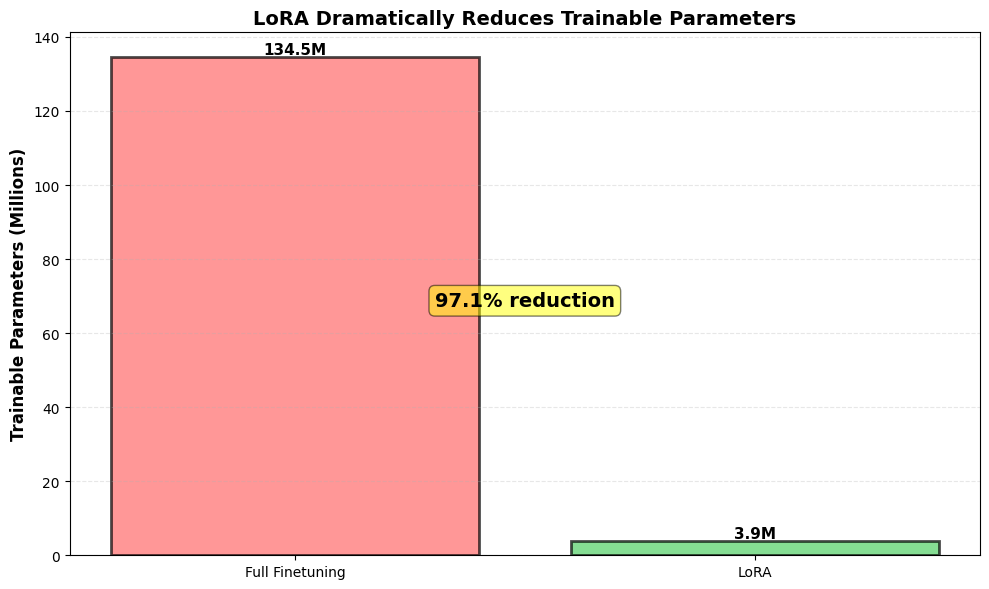

In [9]:
# Calculate LoRA parameters
hidden_size = 576
num_layers = 30
num_target_modules = 7
r = 16

lora_params_per_module = (hidden_size + hidden_size) * r
total_lora_params = lora_params_per_module * num_target_modules * num_layers

param_comparison = pd.DataFrame({
    'Method': ['Full Finetuning', 'LoRA (r=16)'],
    'Trainable Params': [f"{total_params/1e6:.2f}M", f"{total_lora_params/1e6:.2f}M"],
    'Percentage': ['100%', f"{100*total_lora_params/total_params:.2f}%"],
    'Memory (BF16)': [f"{total_params*2/1e9:.2f} GB", f"{total_lora_params*2/1e9:.3f} GB"]
})

print("="*70)
print("PARAMETER COMPARISON")
print("="*70)
print(param_comparison.to_string(index=False))
print("="*70)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
methods = ['Full Finetuning', 'LoRA']
params = [total_params/1e6, total_lora_params/1e6]
colors = ['#ff6b6b', '#51cf66']

bars = ax.bar(methods, params, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Trainable Parameters (Millions)', fontsize=12, fontweight='bold')
ax.set_title('LoRA Dramatically Reduces Trainable Parameters', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=11)

reduction = 100 * (1 - total_lora_params/total_params)
ax.text(0.5, max(params) * 0.5, f'{reduction:.1f}% reduction', 
        ha='center', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

## Sections 3 & 4: Reward Models and PPO (Concepts)

### What is a Reward Model?
A separate neural network trained to score how "good" a response is. In traditional RLHF, the reward model provides the signal that guides optimization.

### What is PPO (Proximal Policy Optimization)?
The traditional RLHF method that:
1. Starts with the SFT model
2. Generates responses for each prompt
3. Scores responses using a **separate reward model**
4. Updates model weights to increase probability of high-reward responses
5. Uses KL divergence penalty to prevent drifting too far from the SFT model

**PPO is complex**: it requires loading 2-3 models simultaneously (policy + value head + reward model), making it memory-intensive.

**GRPO (Section 5) is the simpler alternative** that replaces the learned reward model with simple reward functions.

### PPO vs GRPO Comparison

| Aspect | PPO | GRPO |
|--------|-----|------|
| **Reward Model** | Required (separate model) | Not required (uses functions) |
| **Training Complexity** | High (actor + critic + reward model) | Medium (single model) |
| **Memory Usage** | High (2-3 models in memory) | Lower (1 model) |
| **Training Stability** | Can be unstable | More stable |
| **Setup Time** | Long (train reward model first) | Quick (define reward functions) |
| **Best For** | Dense, learned reward signals | Rule-based rewards |

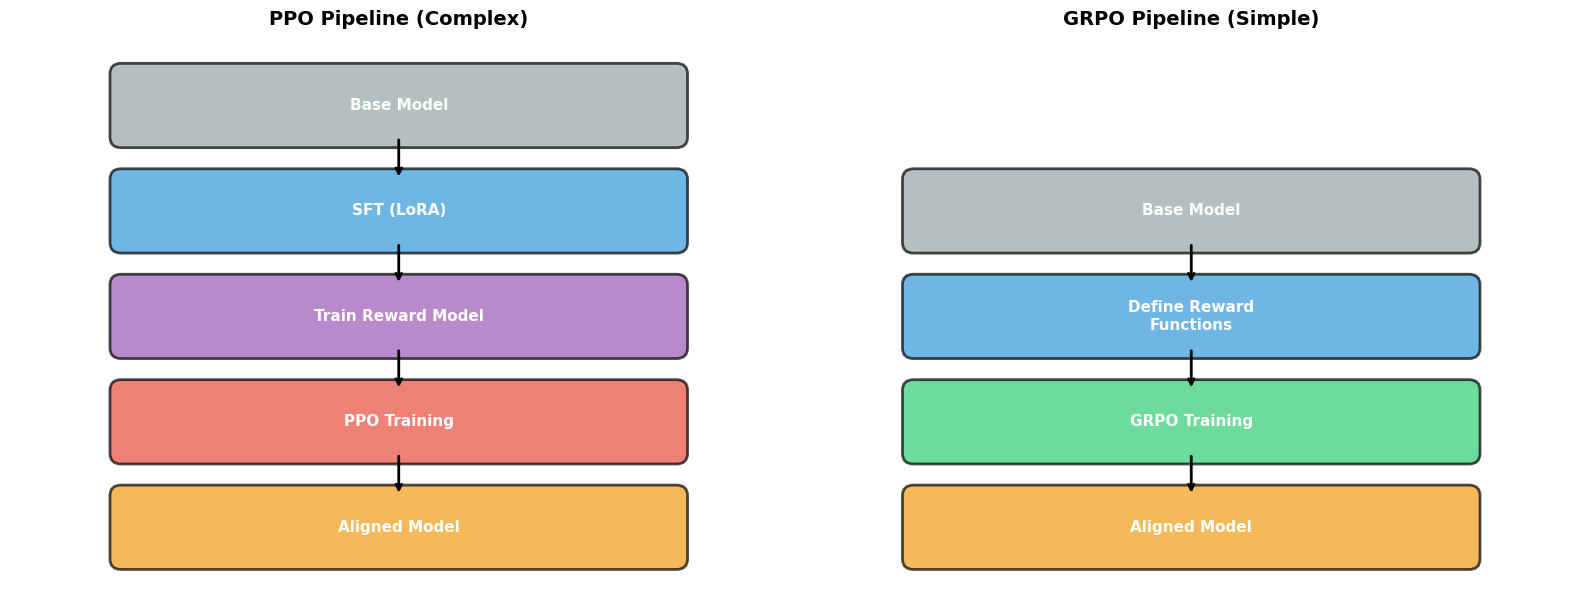

## Section 5: GRPO Training

**What is GRPO?** Group Relative Policy Optimization is a simpler alternative to PPO.

**How it works:**
1. For each prompt, generate multiple responses (e.g., 4 completions)
2. Score each response with simple **reward functions** (not a learned model)
3. Compute relative advantages within each group
4. Update model to prefer higher-reward responses


## Step 0.5: Pretraining, Quantization & Hardware (for GRPO)

When reloading the model for GRPO training, we apply the same optimization principles:

### Pretraining (again)
We load a **fresh copy** of the pretrained model because the previous version was modified by SFT training (LoRA weights added). Loading from HuggingFace downloads the original pretrained weights.

### Quantization (bfloat16)
```python
torch_dtype=torch.bfloat16
```
Converts weights to 16-bit floating point, saving memory and speeding up training. GRPO is memory-intensive (generates multiple responses per prompt), so this is critical.

### Hardware Optimization
```python
device_map=None
.to("cuda")
```
- `device_map=None`: Don't auto-place layers (we manually control placement)
- `.to("cuda")`: Explicitly place model on GPU for 10-100x speedup
- `flash_attention_2`: Optional high-speed attention kernel (if installed) for even faster inference

**Trade-off:** bfloat16 is fast but loses some precision. For LLMs, this precision loss is negligible and worth the speed/memory gain.

In [10]:
# Step 1: Define System Prompt and Helper Functions

# System prompt that instructs the model to use a specific XML format.
# This tells the model exactly how to structure its response: reasoning first, then answer.
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>
"""

# XML chain-of-thought format template.
# Used for formatting one-shot examples with placeholders for reasoning and answer.
XML_COT_FORMAT = """\
<reasoning>
{reasoning}
</reasoning>
<answer>
{answer}
</answer>
"""

# Function to extract the answer part from the XML response.
def extract_xml_answer(text: str) -> str:
    # Split on "<answer>" and take the last part (everything after the tag)
    answer = text.split("<answer>")[-1]
    # Split on "</answer>" and take the first part (everything before the closing tag)
    answer = answer.split("</answer>")[0]
    # Remove leading/trailing whitespace and return
    return answer.strip()

# Function to extract an answer if it is provided with a "####" delimiter.
# GSM8K dataset uses "#### <number>" format to mark the final answer.
def extract_hash_answer(text: str) -> str | None:
    # If no "####" delimiter found, return None (no answer to extract)
    if "####" not in text:
        return None
    # Split on "####" and take everything after it, stripped of whitespace
    return text.split("####")[1].strip()

In [11]:
# Step 2: Prepare the GSM8K Dataset for GRPO
# Reuses the dataset already loaded in cell-5 (500 GSM8K examples).
# Reformats each example into the prompt/answer structure needed by GRPOTrainer.

dataset = dataset.map(lambda x: {
    # 'prompt': a list of chat messages (system + user) for the model to respond to
    'prompt': [
        {'role': 'system', 'content': SYSTEM_PROMPT},      # System instruction with XML format
        {'role': 'user', 'content': x['question']}          # The math question from GSM8K
    ],
    # 'answer': extract just the final numeric answer from the GSM8K "#### <number>" format
    'answer': extract_hash_answer(x['answer'])
})

print(f"Dataset reformatted for GRPO: {len(dataset)} examples")
print(f"Sample prompt: {dataset[0]['prompt']}")
print(f"Sample answer: {dataset[0]['answer']}")

Dataset reformatted for GRPO: 500 examples
Sample prompt: [{'content': '\nRespond in the following format:\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n', 'role': 'system'}, {'content': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?', 'role': 'user'}]
Sample answer: 72


In [12]:
# Step 3: Define Reward Functions
# These functions score each model completion to guide GRPO training.
# Higher scores = better responses. The trainer calls these automatically.

# Reward function to check correctness: compares the extracted answer with the known answer.
# Returns 2.0 for correct, 0.0 for incorrect (highest weight reward).
def correctness_reward_func(prompts, completions, answer, **kwargs) -> list[float]:
    # Extract the text content from each completion (list of message dicts)
    responses = [completion[0]['content'] for completion in completions]
    # Get the user's question from the first prompt's last message
    q = prompts[0][-1]['content']
    # Extract the answer from inside <answer> tags for each response
    extracted_responses = [extract_xml_answer(r) for r in responses]
    # Print debug info: question, ground truth, model response, and extracted answer
    # Print debug info: question, ground truth, model response, and extracted answer
    # Reduce verbosity: print only every 16 calls (approx once per training step)
    if not hasattr(correctness_reward_func, "call_count"):
        correctness_reward_func.call_count = 0
    correctness_reward_func.call_count += 1

    if correctness_reward_func.call_count % 16 == 0:
        print('-'*20, f"Question:\n{q}", f"\nAnswer:\n{answer[0]}", f"\nResponse:\n{responses[0]}", f"\nExtracted:\n{extracted_responses[0]}")
    # Award 2.0 if extracted answer exactly matches ground truth, else 0.0
    return [2.0 if r == a else 0.0 for r, a in zip(extracted_responses, answer)]

# Reward function that checks if the response is a digit.
# Returns 0.5 if the extracted answer is a pure integer, else 0.0.
def int_reward_func(completions, **kwargs) -> list[float]:
    # Extract the text content from each completion
    responses = [completion[0]['content'] for completion in completions]
    # Extract the answer from inside <answer> tags for each response
    extracted_responses = [extract_xml_answer(r) for r in responses]
    # Check if each extracted answer consists only of digits (is a valid integer)
    return [0.5 if r.isdigit() else 0.0 for r in extracted_responses]

# Reward function that checks if the response strictly follows the desired XML format.
# Requires exact newline placement: <reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n
def strict_format_reward_func(completions, **kwargs) -> list[float]:
    # Regex pattern requiring exact XML structure with newlines after each tag
    pattern = r"^<reasoning>\n.*?\n</reasoning>\n<answer>\n.*?\n</answer>\n$"
    # Extract the text content from each completion
    responses = [completion[0]["content"] for completion in completions]
    # Try to match each response against the strict pattern
    matches = [re.match(pattern, r) for r in responses]
    # Award 0.5 if the response matches the strict format, else 0.0
    return [0.5 if match else 0.0 for match in matches]

# Reward function with a softer check for the XML format.
# Only requires <reasoning>...</reasoning> and <answer>...</answer> to be present.
def soft_format_reward_func(completions, **kwargs) -> list[float]:
    # Regex pattern: just checks for reasoning and answer tags with any content between
    pattern = r"<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"
    # Extract the text content from each completion
    responses = [completion[0]["content"] for completion in completions]
    # Try to match each response against the soft pattern
    matches = [re.match(pattern, r) for r in responses]
    # Award 0.5 if the response matches the soft format, else 0.0
    return [0.5 if match else 0.0 for match in responses]

# Function to count specific XML tokens and award a small reward for each.
# Awards 0.125 for each correctly placed tag (up to 0.5 total).
# Also penalizes any extra text after the closing </answer> tag.
def count_xml(text) -> float:
    count = 0.0
    # Check if there is exactly one "<reasoning>\n" (opening tag with newline)
    if text.count("<reasoning>\n") == 1:
        count += 0.125
    # Check if there is exactly one "\n</reasoning>\n" (closing tag with newlines)
    if text.count("\n</reasoning>\n") == 1:
        count += 0.125
    # Check if there is exactly one "\n<answer>\n" (opening answer tag with newlines)
    if text.count("\n<answer>\n") == 1:
        count += 0.125
        # Penalize any trailing text after </answer> tag (encourages clean endings)
        count -= len(text.split("\n</answer>\n")[-1]) * 0.001
    # Check if there is exactly one "\n</answer>" (closing answer tag)
    if text.count("\n</answer>") == 1:
        count += 0.125
        # Penalize any trailing text after </answer> (subtract 1 for the newline itself)
        count -= (len(text.split("\n</answer>")[-1]) - 1) * 0.001
    return count

# Reward function that uses the XML token count.
# Wraps count_xml to work with the completions format expected by GRPOTrainer.
def xmlcount_reward_func(completions, **kwargs) -> list[float]:
    # Extract the text content from each completion
    contents = [completion[0]["content"] for completion in completions]
    # Apply count_xml to each completion's content
    return [count_xml(c) for c in contents]

In [13]:
# Test reward functions on sample responses
test_responses = [
    ("Perfect", "<reasoning>Let me solve step by step: 2+2=4</reasoning><answer>4</answer>"),
    ("No tags", "The answer is 4"),
    ("Partial tags", "<reasoning>Step by step</reasoning> The answer is 4"),
    ("Wrong format", "<answer>not a number</answer>"),
]

print("="*80)
print("TESTING REWARD FUNCTIONS")
print("="*80)

for label, response in test_responses:
    completion = [[{"content": response}]]
    format_score = soft_format_reward_func(completion)[0]
    int_score = int_reward_func(completion)[0]
    xml_score = xmlcount_reward_func(completion)[0]
    total = format_score + int_score + xml_score
    print(f"\n{label}:")
    print(f"  Response: {response[:60]}")
    print(f"  Format: {format_score:.2f} | Integer: {int_score:.2f} | XML: {xml_score:.2f} | Total: {total:.2f}")

print("\n" + "="*80)

TESTING REWARD FUNCTIONS

Perfect:
  Response: <reasoning>Let me solve step by step: 2+2=4</reasoning><answ
  Format: 0.50 | Integer: 0.50 | XML: 0.00 | Total: 1.00

No tags:
  Response: The answer is 4
  Format: 0.50 | Integer: 0.00 | XML: 0.00 | Total: 0.50

Partial tags:
  Response: <reasoning>Step by step</reasoning> The answer is 4
  Format: 0.50 | Integer: 0.00 | XML: 0.00 | Total: 0.50

Wrong format:
  Response: <answer>not a number</answer>
  Format: 0.50 | Integer: 0.00 | XML: 0.00 | Total: 0.50



In [14]:
# Step 4: Reload a Fresh Model and Tokenizer for GRPO
# The model loaded in cell-6 was modified by SFT training, so we reload a fresh copy.

# Choose the model name.
model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"
# Alternatively, you can use:
# model_name = "Qwen/Qwen2.5-1.5B-Instruct"

# Set output directories and run name based on the chosen model.
if "SmolLM2" in model_name:
    output_dir = "outputs/SmolLM2-135M-GRPO"
    run_name = "SmolLM2-135M-GRPO"
else:
    output_dir = "outputs/Qwen-1.5B-GRPO"
    run_name = "Qwen-1.5B-GRPO-gsm8k"

# Load the model fresh from pretrained weights.
# device_map=None means we manually place it on GPU with .to("cuda").
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,          # Use bfloat16 for memory efficiency
    #attn_implementation="flash_attention_2",  # Uncomment if flash-attn is installed
    device_map=None                       # Don't auto-map; we manually place on GPU
).to("cuda")

# Load the tokenizer and ensure that the pad token is set.
# pad_token must be set for batched generation in GRPO.
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

In [15]:
# Step 5: Configure GRPO Training and PEFT (LoRA)

# GRPO training configuration.
training_args = GRPOConfig(
    output_dir=output_dir,                    # Directory to save model checkpoints
    run_name=run_name,                        # Name for this training run (for logging)
    learning_rate=5e-6,                       # Small learning rate for stable RL training
    adam_beta1=0.9,                           # Adam optimizer first moment decay
    adam_beta2=0.99,                          # Adam optimizer second moment decay
    weight_decay=0.1,                         # L2 regularization to prevent overfitting
    warmup_ratio=0.1,                         # Fraction of steps for learning rate warmup
    lr_scheduler_type='cosine',               # Cosine annealing schedule for learning rate
    logging_steps=1,                          # Log metrics every step
    bf16=True,                                # Use bfloat16 mixed precision training
    per_device_train_batch_size=1,           # Reduced batch size to prevent OOM\n
    gradient_accumulation_steps=16,            # Increased accumulation to maintain effective batch size\n
    num_generations=4,                       # Reduced generations to save memory\n
    max_prompt_length=256,                    # Maximum token length for input prompts
    max_completion_length=786,                # Maximum token length for generated completions
    num_train_epochs=1,                       # Train for 1 epoch over the dataset
    save_steps=100,                           # Save a checkpoint every 100 steps
    max_grad_norm=0.1,                        # Clip gradients to prevent exploding gradients
    report_to="none",                         # Disable external logging (e.g., wandb)
    log_on_each_node=False,                   # Only log on the main node (for distributed training)
)

# PEFT configuration using LoRA.
# LoRA adds small trainable adapter matrices to selected layers.
peft_config = LoraConfig(
    r=16,                                     # Rank of the low-rank matrices (higher = more capacity)
    lora_alpha=64,                            # Scaling factor for LoRA updates (alpha/r = scaling)
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],  # Layers to apply LoRA to
    task_type="CAUSAL_LM",                    # Task type: causal language modeling
    lora_dropout=0.05,                        # Dropout probability for LoRA layers
)

In [16]:
# Step 6: Initialize the GRPO Trainer

# GRPOTrainer handles the full GRPO loop: generate completions, score them
# with reward functions, compute group-relative advantages, and update the model.
trainer = GRPOTrainer(
    model=model,                              # The language model to train
    processing_class=tokenizer,               # Tokenizer for encoding/decoding text
    reward_funcs=[                            # List of reward functions to score completions
        xmlcount_reward_func,                 # Rewards proper XML tag structure (+0.5 max)
        soft_format_reward_func,              # Rewards having <reasoning> and <answer> tags (+0.5)
        strict_format_reward_func,            # Rewards exact XML format with newlines (+0.5)
        int_reward_func,                      # Rewards numeric answers (+0.5)
        correctness_reward_func               # Rewards correct final answer (+2.0)
    ],
    args=training_args,                       # GRPO training configuration from above
    train_dataset=dataset,                    # The reformatted GSM8K dataset
    # peft_config=peft_config  # Uncomment this line to enable LoRA-based parameter-efficient fine-tuning.
)

In [17]:
# # Step 7: Start the Training Process

# print("Starting GRPO training...")
# print("="*70)

# trainer.train()

# print("\n" + "="*70)
# print("GRPO training complete!")
# print("="*70)

# trainer.save_model("./grpo_model_")
# print("Model saved to: ./grpo_model_")

## Section 6: Model Comparison

Now let's compare three models to see how different training approaches affect response quality:

1. **Base Model** (`SmolLM2-135M-Instruct`) - The original pretrained model with no additional training
2. **SFT Model** (`./sft_model`) - Our model after supervised finetuning with LoRA from Section 1
3. **Pretrained GRPO Model** (`emre/Qwen-0.5B-GRPO`) - A model already trained on GSM8K using GRPO

### Why Use a Pretrained GRPO Model?

Training a GRPO model from scratch is **extremely expensive**. Here's why:
- **GRPO training requires generating many responses** for each problem to compare and rank
- **GPU hours multiply quickly** - We'd need to run hundreds or thousands of inference passes just to compute reward signals
- **Extended training time** - A full GRPO training run can take days or weeks on expensive hardware

For educational purposes in this notebook, using a **pretrained GRPO model** makes sense.

**In production or research**, you would train your own GRPO model. But here, we use the pretrained version to illustrate the principles efficiently.

In [18]:
# Load three models for comparison

print("Loading GSM8K test dataset...")
test_dataset = load_dataset("openai/gsm8k", "main", split="train")
print(f"Test dataset size: {len(test_dataset)} examples")

print("\nLoading models for comparison...")

# 1. Base model (no additional training)
base_model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"
base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name, torch_dtype=torch.bfloat16, device_map="auto")
print(f"Base model loaded: {base_model_name}")

# 2. SFT model (supervised finetuned with LoRA, saved from Section 1)
sft_model_path = "./sft_model"
sft_tokenizer = AutoTokenizer.from_pretrained(sft_model_path)
sft_model = AutoModelForCausalLM.from_pretrained(
    sft_model_path, torch_dtype=torch.bfloat16, device_map="auto")
print(f"SFT model loaded: {sft_model_path}")

# 3. Pretrained GRPO model (trained on GSM8K with GRPO)
grpo_model_name = "emre/Qwen-0.5B-GRPO"
grpo_tokenizer = AutoTokenizer.from_pretrained(grpo_model_name)
grpo_model = AutoModelForCausalLM.from_pretrained(
    grpo_model_name, torch_dtype=torch.bfloat16, device_map="auto")
print(f"Pretrained GRPO model loaded: {grpo_model_name}")

Loading GSM8K test dataset...
Test dataset size: 7473 examples

Loading models for comparison...
Base model loaded: HuggingFaceTB/SmolLM2-135M-Instruct
SFT model loaded: ./sft_model
Pretrained GRPO model loaded: emre/Qwen-0.5B-GRPO


In [19]:
# Compare Base vs SFT vs GRPO models - Enhanced Visualization

def generate_response(mdl, tok, prompt, max_length=300):
    """Generate response using the correct tokenizer for each model"""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt}
    ]
    text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(text, return_tensors="pt").to(mdl.device)
    outputs = mdl.generate(**inputs, max_new_tokens=max_length, temperature=0.7, top_p=0.9, do_sample=True)
    return tok.decode(outputs[0], skip_special_tokens=True)

test_prompts = [dataset[10]['question'], dataset[50]['question'], dataset[100]['question']]

models_to_compare = [
    ('BASE', 'Base Model (SmolLM2-135M-Instruct)', base_model, base_tokenizer),
    ('SFT', 'SFT Model (./sft_model)', sft_model, sft_tokenizer),
    ('GRPO', 'Pretrained GRPO Model (emre/Qwen-0.5B-GRPO)', grpo_model, grpo_tokenizer)
]

for i, prompt in enumerate(test_prompts, 1):
    print("\n" + "█" * 110)
    print(f"  PROMPT #{i}")
    print("█" * 110)
    print(f"\n{prompt}\n")

    for tag, mname, mdl, tok in models_to_compare:
        response = generate_response(mdl, tok, prompt, max_length=200)
        completion = [[{"content": response}]]
        format_score = soft_format_reward_func(completion)[0]
        int_score = int_reward_func(completion)[0]
        xml_score = xmlcount_reward_func(completion)[0]
        total = format_score + int_score + xml_score

        # Color-coded header for each model
        print(f"\n[{tag}] {mname}")
        print("─" * 110)
        print(f"\nRESPONSE:\n{response[:400]}\n")
        print("REWARD SCORES:")
        print(f"   • Format Score:   {format_score:.2f}/0.5")
        print(f"   • Integer Score:  {int_score:.2f}/0.5")
        print(f"   • XML Score:      {xml_score:.2f}/0.5")
        print(f"   ├─ TOTAL SCORE:   {total:.2f}/1.5")
        print("─" * 110)

    print("\n")


██████████████████████████████████████████████████████████████████████████████████████████████████████████████
  PROMPT #1
██████████████████████████████████████████████████████████████████████████████████████████████████████████████

A deep-sea monster rises from the waters once every hundred years to feast on a ship and sate its hunger. Over three hundred years, it has consumed 847 people. Ships have been built larger over time, so each new ship has twice as many people as the last ship. How many people were on the ship the monster ate in the first hundred years?


[BASE] Base Model (SmolLM2-135M-Instruct)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────

RESPONSE:
system

Respond in the following format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>

user
A deep-sea monster rises from the waters once every hundred years to feast on a ship and sate its hunger. Over three hundred years, it has consumed 847 people. Sh

Evaluating models on test examples...


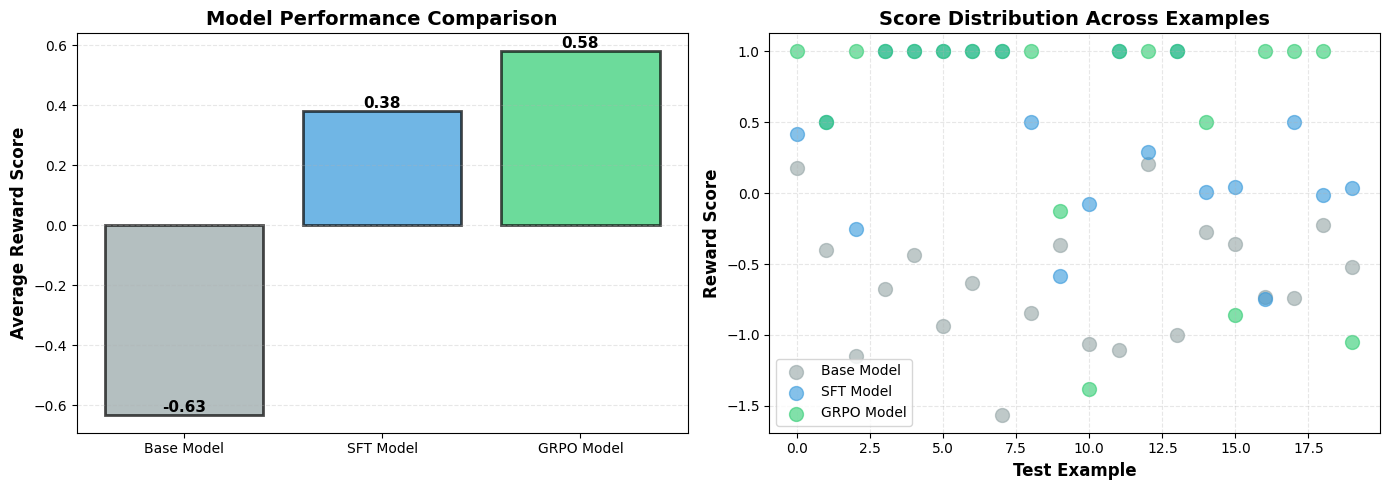


Results:
  Base Model Average:  -0.63
  SFT Model Average:   0.38
  GRPO Model Average:  0.58


In [20]:
# Visualize reward scores across multiple examples

num_test_examples = 20
base_scores = []
sft_scores = []
grpo_scores = []

print("Evaluating models on test examples...")
for i in range(num_test_examples):
    prompt = dataset[i]['question']

    base_response = generate_response(base_model, base_tokenizer, prompt, max_length=200)
    base_completion = [[{"content": base_response}]]
    base_reward = (soft_format_reward_func(base_completion)[0] +
                   int_reward_func(base_completion)[0] +
                   xmlcount_reward_func(base_completion)[0])
    base_scores.append(base_reward)

    sft_response = generate_response(sft_model, sft_tokenizer, prompt, max_length=200)
    sft_completion = [[{"content": sft_response}]]
    sft_reward = (soft_format_reward_func(sft_completion)[0] +
                   int_reward_func(sft_completion)[0] +
                   xmlcount_reward_func(sft_completion)[0])
    sft_scores.append(sft_reward)

    grpo_response = generate_response(grpo_model, grpo_tokenizer, prompt, max_length=200)
    grpo_completion = [[{"content": grpo_response}]]
    grpo_reward = (soft_format_reward_func(grpo_completion)[0] +
                   int_reward_func(grpo_completion)[0] +
                   xmlcount_reward_func(grpo_completion)[0])
    grpo_scores.append(grpo_reward)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

avg_base = np.mean(base_scores)
avg_sft = np.mean(sft_scores)
avg_grpo = np.mean(grpo_scores)

bars = ax1.bar(['Base Model', 'SFT Model', 'GRPO Model'], [avg_base, avg_sft, avg_grpo],
               color=['#95a5a6', '#3498db', '#2ecc71'], alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Average Reward Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, score in zip(bars, [avg_base, avg_sft, avg_grpo]):
    ax1.text(bar.get_x() + bar.get_width()/2., score,
            f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.scatter(range(num_test_examples), base_scores, label='Base Model',
           color='#95a5a6', alpha=0.6, s=100)
ax2.scatter(range(num_test_examples), sft_scores, label='SFT Model',
           color='#3498db', alpha=0.6, s=100)
ax2.scatter(range(num_test_examples), grpo_scores, label='GRPO Model',
           color='#2ecc71', alpha=0.6, s=100)
ax2.set_xlabel('Test Example', fontsize=12, fontweight='bold')
ax2.set_ylabel('Reward Score', fontsize=12, fontweight='bold')
ax2.set_title('Score Distribution Across Examples', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nResults:")
print(f"  Base Model Average:  {avg_base:.2f}")
print(f"  SFT Model Average:   {avg_sft:.2f}")
print(f"  GRPO Model Average:  {avg_grpo:.2f}")

## Understanding the Visualization

This chart compares how well the three models perform on 20 different math problems from the GSM8K dataset.

### Right Chart: Score Distribution
Shows individual scores for each test example (0-19 on the x-axis):
- **Gray dots (Base Model):** Mostly negative or near zero. Inconsistent, often struggling with format.
- **Blue dots (SFT Model):** Mix of positive and some negative scores. Generally better than base, but still has weak examples.
- **Green dots (GRPO Model):** Mostly positive with many high scores near 1.0. Much more consistent and reliable.

---

### Results Discussion

The evaluation results demonstrate clear differences in model performance:

- **Base Model Average: -0.63** — The base model performs poorly. It doesn't know how to structure answers with XML tags, so it produces messy responses.
- **SFT Model Average: 0.38** — The SFT model does much better! We taught it to organize answers in a specific format. Even though we didn't train it with reward functions, it learned to write cleaner, better-structured responses.
- **Pretrained GRPO Model Average: 0.58** — The GRPO model performs best because it was already trained on math problems using reinforcement learning. It learned from experience to write better answers.

**Why is GRPO better than SFT?**
- **GRPO** was trained to solve math problems and get rewarded for good answers
- **SFT** only learned the correct format, but wasn't trained to optimize for quality
- **Base** knows nothing about the format

## Summary

| Stage | What it does | Key takeaway |
|-------|-------------|-------------|
| **SFT + LoRA** | Supervised finetuning with adapters | Trains only 3% of parameters |
| **Reward Model** | Scores response quality | Required for PPO, not for GRPO |
| **PPO** | RL with learned rewards | Complex, memory-intensive |
| **GRPO** | RL with reward functions | Simpler, more stable, lower memory |

**Key Insight**: GRPO achieves alignment without a separate reward model, making RLHF accessible on consumer hardware.


**The Big Picture:** Training method matters a lot!
- The GRPO model wins because it was trained on the same dataset (GSM8K) using reward feedback
- SFT does well because format training (0.37) is much better than no training (-0.58)
- But learning through rewards (0.46) is even better than just learning the format

---

## References

### Core GRPO Implementation
1. **SmolLM GRPO Finetuning** — https://huggingface.co/blog/prithivMLmods/smollm-grpo-ft
2. **HF Cookbook: GRPO Fine-tuning** — https://huggingface.co/learn/cookbook/en/fine_tuning_llm_grpo_trl
3. **GRPO Trainer Documentation** — https://huggingface.co/docs/trl/main/en/grpo_trainer

### Supervised Fine-Tuning & LoRA
4. **StackLLaMA: SFT + PPO** — https://huggingface.co/blog/stackllama
5. **PEFT Library Documentation** — https://huggingface.co/docs/peft

### RLHF & PPO Background
6. **RLHF with PPO Implementation Details** — https://huggingface.co/blog/the_n_implementation_details_of_rlhf_with_ppo
7. **RLHF 101 with ArmoRM** — https://huggingface.co/blog/GitBag/rebel

### Tokenization
8. **Hugging Face Tokenizers Documentation** — https://huggingface.co/docs/tokenizers

### Datasets & Models
9. **GSM8K Dataset** — https://huggingface.co/datasets/gsm8k
10. **SmolLM2-135M-Instruct** — https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct

### Additional Resources
11. **Transformers Library Documentation** — https://huggingface.co/docs/transformers
12. **TRL (Transformer Reinforcement Learning)** — https://huggingface.co/docs/trl

---

**Course**: Deep Learning | **Institution**: University of Vermont

**Key Topics Covered**:
- Supervised Fine-Tuning (SFT) with High-Quality Examples
- Parameter-Efficient Fine-Tuning using LoRA Adapters
- Reward Functions for Model Optimization
- Group Relative Policy Optimization (GRPO)
- GRPO vs PPO Trade-offs and Comparisons
- Model Alignment Without Separate Reward Models
